# Sales Prediction Using Advertising Data

**Objective:** Build a regression model that predicts product sales based on advertising spend across TV, Radio, and Newspaper channels.

**Dataset:** Advertising.csv — 200 records with TV, Radio, Newspaper advertising budgets (in thousands of dollars) and resulting Sales (in thousands of units).

**Approach:** EDA → Visualisation → Train/test split → Train multiple regression models → Evaluate → Interpret results.

## 1. Import Libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and preprocessing
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

In [3]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

# Clean extra index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 3. Basic Exploratory Data Analysis

In [4]:
# Shape of the dataset
print("Shape:", df.shape)

# Data types
print("\nData types:\n", df.dtypes)

# Missing values
print("\nNull values:\n", df.isnull().sum())

# Descriptive statistics
df.describe()

Shape: (200, 4)

Data types:
 TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

Null values:
 TV           0
radio        0
newspaper    0
sales        0
dtype: int64


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 4. Pairplot: Relationship Between Features and Sales


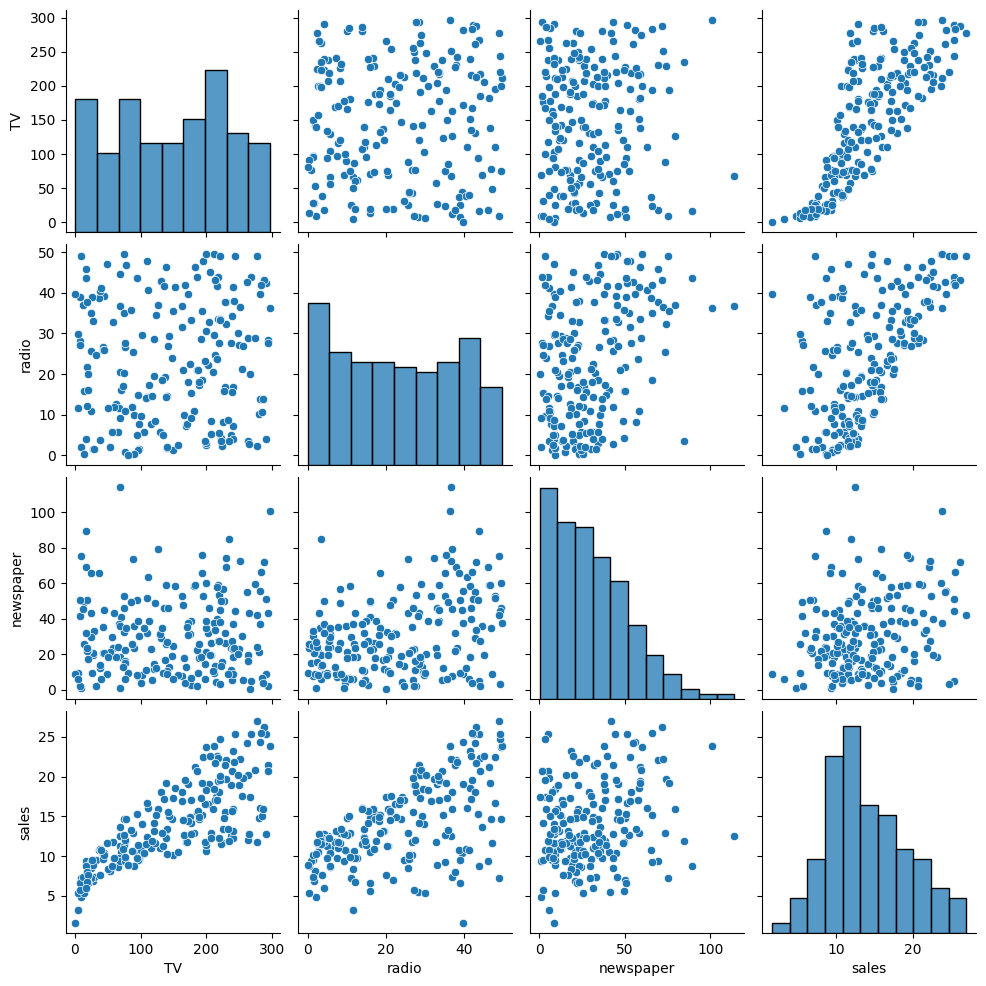

In [5]:
# Pairplot to see all relationships together
sns.pairplot(df)
plt.show()

## 5. Sales vs Each Advertising Channel

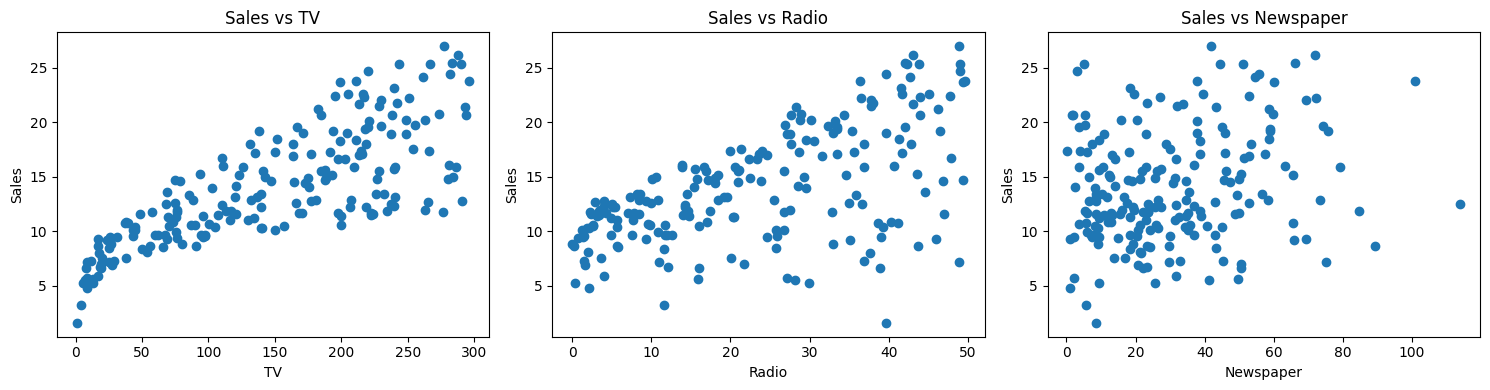

In [6]:
# Individual scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['TV'], df['sales'])
axes[0].set_xlabel('TV')
axes[0].set_ylabel('Sales')
axes[0].set_title('Sales vs TV')

axes[1].scatter(df['radio'], df['sales'])
axes[1].set_xlabel('Radio')
axes[1].set_ylabel('Sales')
axes[1].set_title('Sales vs Radio')

axes[2].scatter(df['newspaper'], df['sales'])
axes[2].set_xlabel('Newspaper')
axes[2].set_ylabel('Sales')
axes[2].set_title('Sales vs Newspaper')

plt.tight_layout()
plt.show()

**Observations:**
- Sales has a strong, near-linear positive relationship with TV spend.
- Sales has a moderate positive relationship with radio spend, with more scatter than TV.
- Sales shows almost no clear relationship with newspaper spend; the points are scattered with no obvious trend.
- TV is the strongest predictor of sales, followed by radio, while newspaper contributes the least.

## 6. Correlation Heatmap

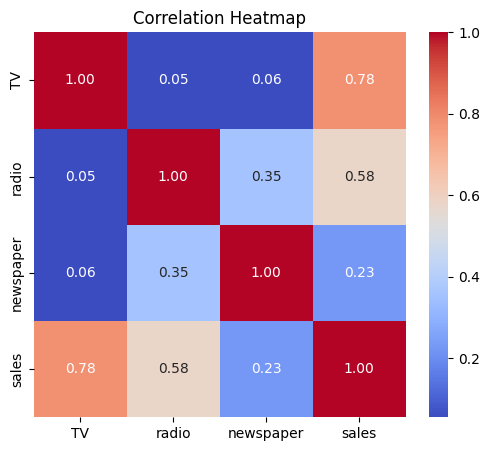

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

**Observations:**
- TV has the highest correlation with sales.
- Radio shows a moderate correlation with sales.
- Newspaper shows the weakest correlation with sales.
- The numerical values confirm the visual patterns observed in the scatter plots.

## 7. Train/Test Split

In [15]:
# Select Features (X) and Target (y)
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

# Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display dataset shapes
print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (160, 3)
Test set shape: (40, 3)


## 8. Train and Evaluate the Models

In [14]:
# Define the regression models for comparison
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    # Model Training
    model.fit(X_train, y_train)

    # Prediction on Test set
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Calculate Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2 Score": r2}

    print("=" * 40)
    print(f"Model: {name}")
    print("=" * 40)
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

# Display Metrics Summary Table
results_df = pd.DataFrame(results).T.round(4)
results_df

Model: Linear Regression
MAE:      1.4608
RMSE:     1.7816
R2 Score: 0.8994

Model: Random Forest
MAE:      0.6201
RMSE:     0.7686
R2 Score: 0.9813



,MAE,RMSE,R2 Score
Linear Regression,1.4608,1.7816,0.8994
Random Forest,0.6201,0.7686,0.9813


**Observations:**
- Random Forest clearly outperforms Linear Regression on all three metrics: lower MAE (0.62 vs 1.46), lower RMSE (0.76 vs 1.78), and higher R² (0.98 vs 0.90).
- This suggests the true relationship between advertising spend and sales is not fully linear — there may be interaction effects between channels (e.g. TV and radio together) that Linear Regression cannot capture but Random Forest can.
- Random Forest is therefore the better-performing model here, though Linear Regression remains useful as a simple, interpretable baseline.

## 9. Actual vs Predicted Sales

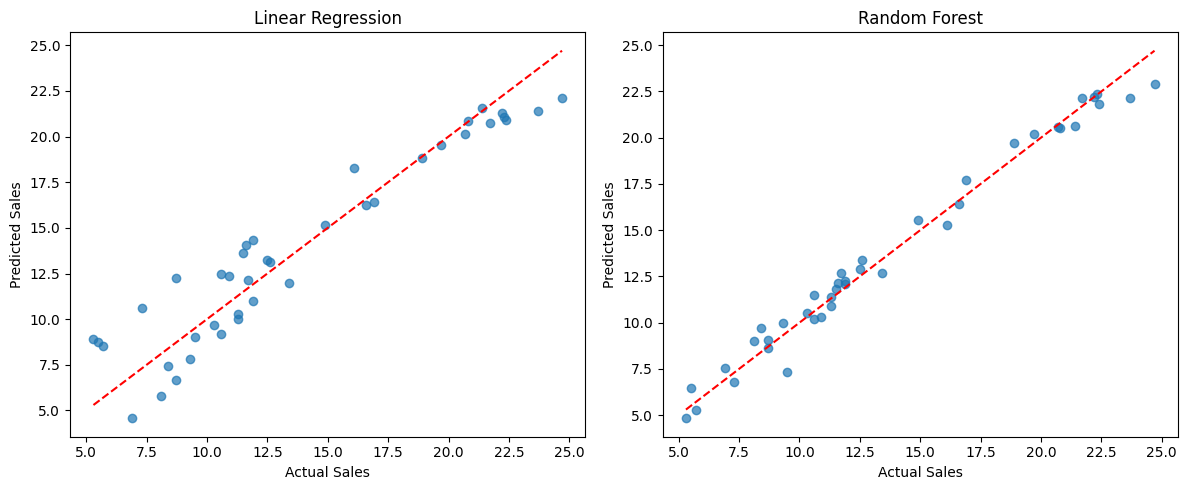

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 10. Residual Plot

**Observations:**
- In the Random Forest plot, points lie much closer to the red diagonal line than in the Linear Regression plot, confirming its higher R² score.
- Linear Regression tends to slightly overpredict at low actual sales and underpredict at high actual sales.

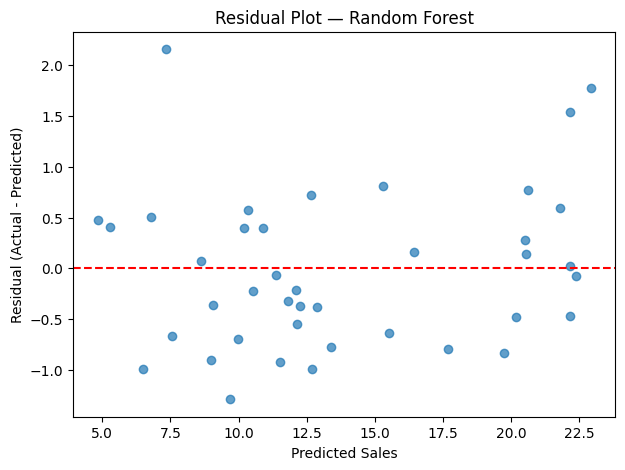

In [12]:
# Residual = Actual Value - Predicted Value
best_model_name = "Random Forest"
residuals = y_test - predictions[best_model_name]

plt.figure(figsize=(7, 5))
plt.scatter(predictions[best_model_name], residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

**Observations:**
- The residuals are scattered around 0 without a clear systematic pattern (no curve or funnel shape), which suggests Random Forest's errors are unbiased.
- The spread of residuals looks reasonably even across the range of predicted sales, confirming model reliability.

## 11. Which Advertising Channel Matters Most?

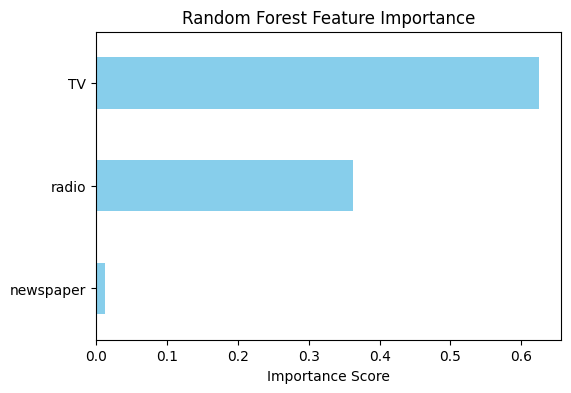

Linear Regression Coefficients:
TV           0.044730
radio        0.189195
newspaper    0.002761
dtype: float64


In [13]:
# Random Forest Feature Importance
rf_model = models["Random Forest"]
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(6, 4))
importance.plot(kind='barh', color='skyblue')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# Linear Regression Coefficients (for comparison)
lr_model = models["Linear Regression"]
coef = pd.Series(lr_model.coef_, index=X.columns)
print("Linear Regression Coefficients:")
print(coef)

**Observations:**
- TV has the highest feature importance in the Random Forest model, followed by radio, with newspaper contributing the least.
- The Linear Regression coefficients show the same ranking: TV has the largest positive impact, radio moderate, and newspaper close to zero.
- This confirms our EDA and correlation findings: TV is the primary driver of sales, followed by radio, while newspaper advertising has negligible impact.

## 12. Conclusion & Business Recommendations

**Summary of Findings:**
- **Best Model:** **Random Forest Regressor** achieved superior performance with an **R² score of 0.98** and an **MAE of 0.62**, outperforming Linear Regression (R² = 0.90, MAE = 1.46).
- **Key Driver:** **TV advertising** is by far the most influential variable affecting sales, followed by **Radio**.
- **Least Driver:** **Newspaper advertising** has little to no measurable effect on product sales.

**Actionable Business Strategy:**
1. **Focus Investment on TV:** Allocate the majority of the marketing budget to TV, as it delivers the highest return on investment.
2. **Utilize Radio strategically:** Maintain an optimal radio ad spend to complement TV campaigns.
3. **Reallocate Newspaper Budget:** Reduce or reallocate funds from newspaper ads toward TV or digital channels to maximize overall revenue.

**Limitation:** This dataset is small (200 samples) and only captures direct spend-to-sales relationships. It does not account for factors like seasonality, competitor activity, or long-term brand effects, so real-world results may vary.